<a href="https://colab.research.google.com/github/100579143/Successful-_games/blob/main/Successful__games_YC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Proyecto Final - Predicción de éxito en videojuegos

# Carga de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Carga del dataset



```
En primer lugar, se carga el dataset de ventas de videojuegos y se realiza una inspección inicial para comprobar que la lectura del archivo es correcta.
```



In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("video_games_sales.csv")
df.head()

Saving video_games_sales.csv to video_games_sales.csv


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


##Inspección inicial del dataset
En esta fase se revisa la estructura general del conjunto de datos: dimensiones, nombres de columnas, tipos de variables, valores nulos y posibles registros duplicados.

In [5]:
# Ver dimensiones del dataset
df.shape


(16598, 11)

In [6]:
# Ver nombres de las columnas
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [7]:
# Resumen general del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [8]:
# Contar valores nulos por columna
df.isnull().sum().sort_values(ascending=False)

,0
Year,271
Publisher,58
Rank,0
Platform,0
Name,0
Genre,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [9]:
# Contar filas duplicadas
df.duplicated().sum()

np.int64(0)

# Limpieza y preparación de datos

## Selección de variables relevantes

Para este proyecto se seleccionan únicamente las variables que se utilizarán para la predicción del éxito del videojuego, junto con la variable de ventas globales, necesaria para construir la variable objetivo.

Las variables seleccionadas son:

Platform

*   Year
*   Genre
*   Publisher
*   Global_Sales



In [10]:
# Seleccionamos solo las columnas necesarias para el proyecto
cols = ['Platform', 'Year', 'Genre', 'Publisher', 'Global_Sales']

# Creamos un nuevo DataFrame solo con esas columnas
df = df[cols].copy()

# Mostramos las primeras filas del nuevo DataFrame
df.head()

,Platform,Year,Genre,Publisher,Global_Sales
0,Wii,2006.0,Sports,Nintendo,82.74
1,NES,1985.0,Platform,Nintendo,40.24
2,Wii,2008.0,Racing,Nintendo,35.82
3,Wii,2009.0,Sports,Nintendo,33.00
4,GB,1996.0,Role-Playing,Nintendo,31.37


## Limpieza de datos

Se revisan y tratan los valores nulos del dataset para asegurar que los datos sean adecuados para el entrenamiento de modelos de machine learning.

En concreto:

*  se eliminan filas con Global_Sales nulo, ya que esta variable es imprescindible para construir la etiqueta objetivo
*  se rellenan los valores faltantes de variables categóricas con "Unknown"
*  se rellenan los valores faltantes de Year con la mediana

In [11]:
# Comprobar cuántos valores nulos hay en cada columna
df.isnull().sum()

# Eliminamos filas donde falte la venta global
df = df.dropna(subset=['Global_Sales'])

# Rellenamos valores faltantes en columnas categóricas con 'Unknown'
df['Platform'] = df['Platform'].fillna('Unknown')
df['Genre'] = df['Genre'].fillna('Unknown')
df['Publisher'] = df['Publisher'].fillna('Unknown')

# Rellenamos valores faltantes en el año con la mediana
df['Year'] = df['Year'].fillna(df['Year'].median())

# Comprobamos de nuevo si quedan valores nulos
df.isnull().sum()

,0
Platform,0
Year,0
Genre,0
Publisher,0
Global_Sales,0


## Estadísticas descriptivas iniciales
Antes de construir el modelo, conviene explorar algunas estadísticas descriptivas básicas para comprender mejor la estructura del dataset y la distribución de las variables principales.

In [12]:
# Resumen estadístico de variables numéricas
df.describe()

,Year,Global_Sales
count,16598.000000,16598.000000
mean,2006.416134,0.537441
std,5.781686,1.555028
min,1980.000000,0.010000
25%,2003.000000,0.060000
50%,2007.000000,0.170000
75%,2010.000000,0.470000
max,2020.000000,82.740000


In [13]:
# Número de valores únicos por columna
df.nunique()

,0
Platform,31
Year,39
Genre,12
Publisher,578
Global_Sales,623


In [14]:
# Distribución del año de lanzamiento
df['Year'].describe()

,Year
count,16598.000000
mean,2006.416134
std,5.781686
min,1980.000000
25%,2003.000000
50%,2007.000000
75%,2010.000000
max,2020.000000


In [15]:
# Frecuencia de las plataformas más comunes
df['Platform'].value_counts().head(10)

,count
Platform,
DS,2163
PS2,2161
PS3,1329
Wii,1325
X360,1265
PSP,1213
PS,1196
PC,960
XB,824


In [16]:
# Frecuencia de los géneros más comunes
df['Genre'].value_counts().head(10)

,count
Genre,
Action,3316
Sports,2346
Misc,1739
Role-Playing,1488
Shooter,1310
Adventure,1286
Racing,1249
Platform,886
Simulation,867


In [17]:
# Frecuencia de los publishers más comunes
df['Publisher'].value_counts().head(10)

,count
Publisher,
Electronic Arts,1351
Activision,975
Namco Bandai Games,932
Ubisoft,921
Konami Digital Entertainment,832
THQ,715
Nintendo,703
Sony Computer Entertainment,683
Sega,639


## Creación de la variable objetivo

Se define como videojuego exitoso aquel que supera 1 millón de ventas globales. A partir de ello se crea una variable binaria llamada Successful, que será la utilizada por los modelos de clasificación.

*  1 si el juego supera 1 millón de ventas globales
*  0 si no lo supera

Este umbral se ha escogido por ser una referencia clara e interpretable desde el punto de vista comercial. Además, permite convertir el problema en una tarea de clasificación binaria, diferenciando entre juegos con éxito comercial relevante y juegos con menor impacto en ventas. Aunque este criterio simplifica una realidad más compleja, resulta adecuado para plantear un problema de machine learning supervisado y comparar distintos modelos de clasificación.

In [18]:
# Creamos la variable objetivo
df['Successful'] = (df['Global_Sales'] > 1.0).astype(int)

# Mostrar algunas filas para comprobar el resultado
df[['Global_Sales', 'Successful']].head()

,Global_Sales,Successful
0,82.74,1
1,40.24,1
2,35.82,1
3,33.00,1
4,31.37,1


In [19]:
# Ver cuántos juegos exitosos y no exitosos hay
df['Successful'].value_counts()


,count
Successful,
0,14544
1,2054


In [20]:
# Ver la proporción de cada clase
df['Successful'].value_counts(normalize=True)

,proportion
Successful,
0,0.87625
1,0.12375


# Análisis exploratorio de datos

En esta sección se estudia la distribución de la variable objetivo y su relación con distintas variables del dataset, como el año, el género, la plataforma y la publisher. El objetivo es extraer patrones e información útil antes de construir los modelos.

## 1. Distribución de la variable objetivo

Primero se analiza cuántos videojuegos son exitosos y cuántos no. Este paso es muy importante porque permite detectar si existe desbalance entre clases.

In [21]:
# Importamos matplotlib para hacer gráficos
import matplotlib.pyplot as plt

# Conteo de videojuegos exitosos y no exitosos
df['Successful'].value_counts()

,count
Successful,
0,14544
1,2054


In [22]:
# Proporción de cada clase
df['Successful'].value_counts(normalize=True)

,proportion
Successful,
0,0.87625
1,0.12375


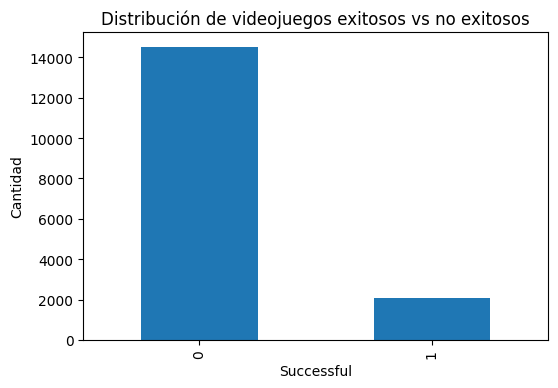

In [23]:
# Gráfico de barras de la variable objetivo
df['Successful'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribución de videojuegos exitosos vs no exitosos")
plt.xlabel("Successful")
plt.ylabel("Cantidad")
plt.show()

**Interpretación**

A partir de este análisis se observa que el dataset está claramente desbalanceado, ya que hay muchos más videojuegos no exitosos que exitosos. Esto es relevante porque, en contextos así, la accuracy por sí sola puede resultar engañosa. Por eso, más adelante se utilizarán también métricas como F1-score y ROC-AUC.

## 2. Distribución de las ventas globales

Se estudia la distribución de Global_Sales para comprender cómo se reparten las ventas de los videojuegos en el dataset.

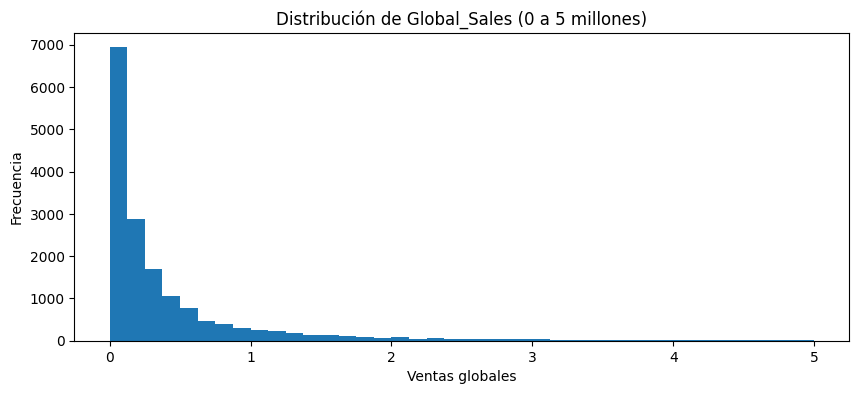

In [24]:
# Resumen estadístico de las ventas globales
df['Global_Sales'].describe()

# Histograma de ventas globales
plt.figure(figsize=(10,4))
plt.hist(df['Global_Sales'], bins=40, range=(0, 5))
plt.title("Distribución de Global_Sales (0 a 5 millones)")
plt.xlabel("Ventas globales")
plt.ylabel("Frecuencia")
plt.show()

**Interpretación**

La distribución de Global_Sales está fuertemente sesgada hacia la derecha. La mayoría de los videojuegos presentan ventas globales bajas, mientras que solo unos pocos títulos alcanzan ventas muy elevadas. Esto indica que el éxito comercial extremo es poco frecuente en el dataset y ayuda a explicar por qué la clase de videojuegos exitosos es minoritaria.

## 3. Análisis temporal: número de juegos y tasa de éxito por año
Se analiza cómo varía el número de videojuegos lanzados por año y cómo cambia la proporción de juegos exitosos a lo largo del tiempo.

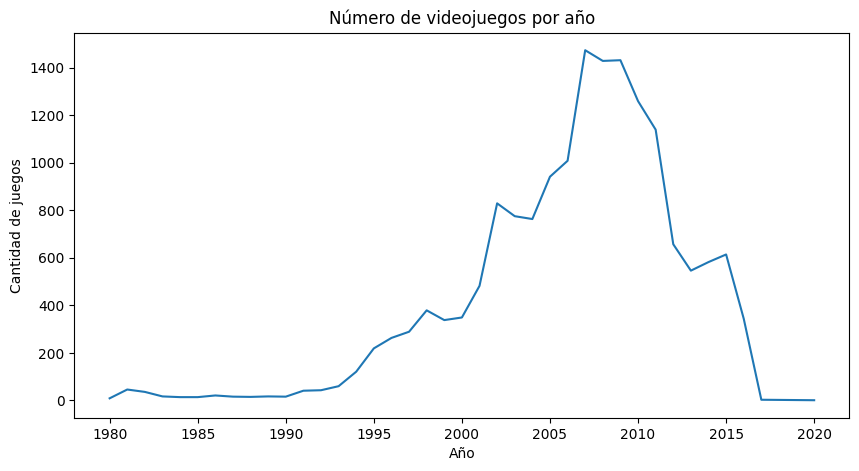

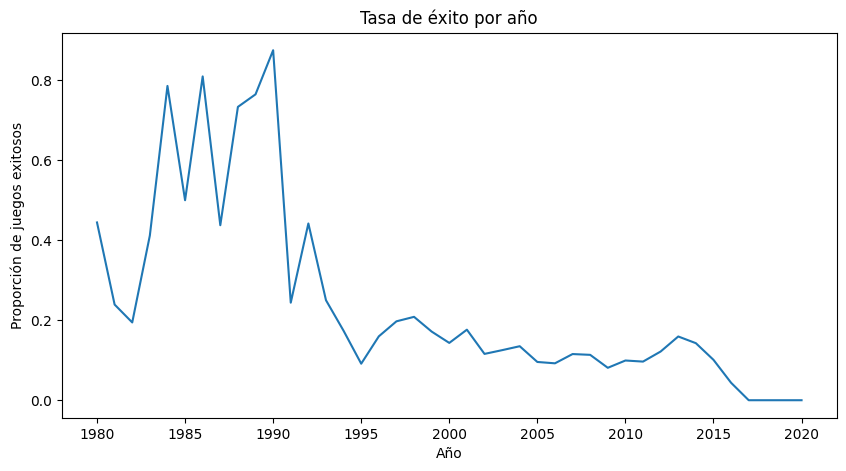

In [25]:
# Número de juegos por año
games_per_year = df['Year'].value_counts().sort_index()
games_per_year.plot(kind='line', figsize=(10,5))
plt.title("Número de videojuegos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos")
plt.show()

# Tasa media de éxito por año
year_success = df.groupby('Year')['Successful'].mean()
year_success.plot(kind='line', figsize=(10,5))
plt.title("Tasa de éxito por año")
plt.xlabel("Año")
plt.ylabel("Proporción de juegos exitosos")
plt.show()

### Interpretación

El análisis temporal muestra que el número de videojuegos publicados no se mantiene constante a lo largo del tiempo. Se observa un crecimiento progresivo desde mediados de los años noventa hasta alcanzar un máximo aproximado entre 2007 y 2009, seguido de un descenso en los años posteriores.

Además, la tasa de éxito varía según el año de lanzamiento. En los primeros años del dataset aparecen valores más altos pero también más inestables, probablemente porque hay menos videojuegos registrados en ese periodo. A partir de mediados de los noventa, la proporción de juegos exitosos disminuye y se vuelve más estable en niveles inferiores.

En conjunto, estos resultados sugieren que el año de publicación es una variable relevante para la predicción, ya que el contexto del mercado y la probabilidad de éxito cambian con el paso del tiempo. No obstante, los primeros y últimos años deben interpretarse con cautela, ya que presentan menos observaciones.

## 4. Géneros más frecuentes y tasa de éxito por género
Se estudia qué géneros son más frecuentes en el dataset y cuál es la proporción de videojuegos exitosos en cada uno de ellos.


In [26]:
# Conteo de géneros
df['Genre'].value_counts().head(10)

,count
Genre,
Action,3316
Sports,2346
Misc,1739
Role-Playing,1488
Shooter,1310
Adventure,1286
Racing,1249
Platform,886
Simulation,867


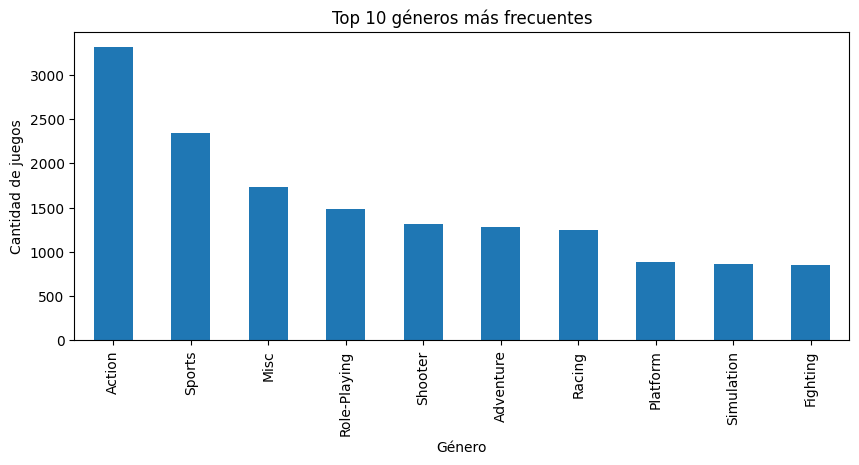

In [27]:
# Gráfico de géneros más frecuentes
df['Genre'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 géneros más frecuentes")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.show()


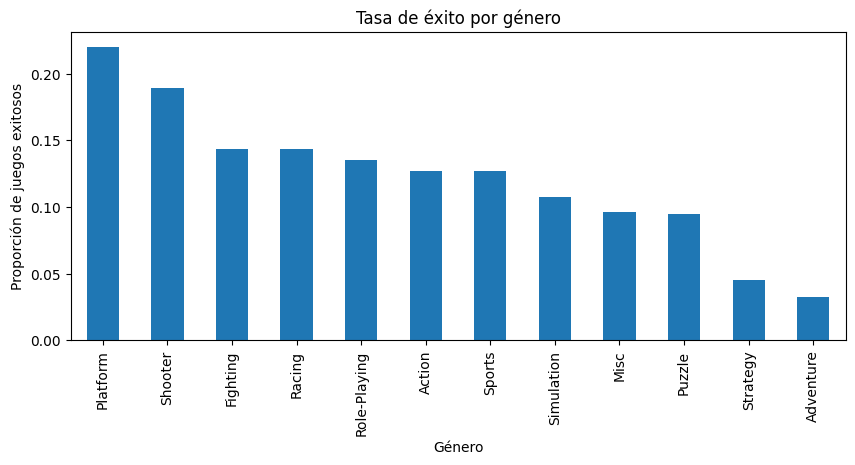

In [28]:
# Tasa de éxito por género
genre_success = df.groupby('Genre')['Successful'].mean().sort_values(ascending=False)
genre_success.plot(kind='bar', figsize=(10,4))
plt.title("Tasa de éxito por género")
plt.xlabel("Género")
plt.ylabel("Proporción de juegos exitosos")
plt.show()

### Interpretación

El análisis por género muestra, en primer lugar, que no todos los géneros tienen la misma presencia en el dataset. El género **Action** es el más frecuente con diferencia, seguido por **Sports** y **Misc**, lo que indica que una parte importante de los videojuegos registrados pertenece a estas categorías.

Sin embargo, al analizar la **tasa de éxito por género**, se observa que los géneros más abundantes no son necesariamente los que presentan una mayor proporción de títulos exitosos. En particular, **Platform** y **Shooter** destacan por tener tasas de éxito relativamente altas, mientras que otros géneros como **Strategy** y **Adventure** muestran proporciones menores.

Esto sugiere que el género del videojuego es una variable relevante para la predicción, ya que no solo existe una diferencia en la cantidad de juegos publicados por género, sino también en la probabilidad de que esos juegos sean exitosos.

## 5. Plataformas más frecuentes y tasa de éxito por plataforma
También se analiza la frecuencia de aparición de las plataformas y su tasa de éxito.

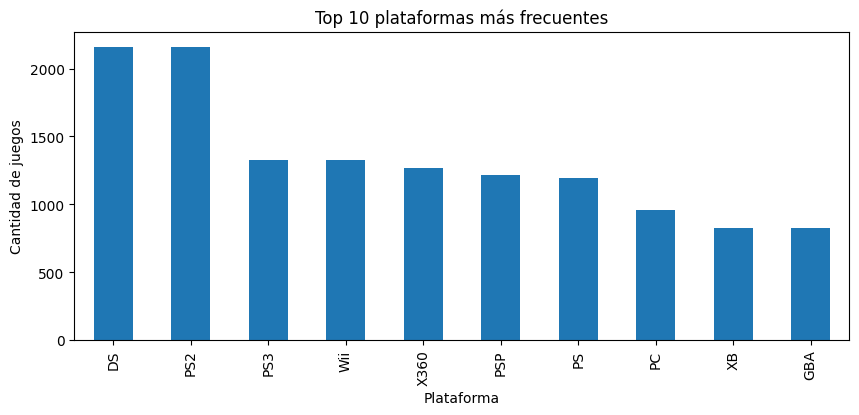

In [29]:
# Conteo de plataformas
df['Platform'].value_counts().head(10)

# Gráfico de plataformas más frecuentes
df['Platform'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 plataformas más frecuentes")
plt.xlabel("Plataforma")
plt.ylabel("Cantidad de juegos")
plt.show()

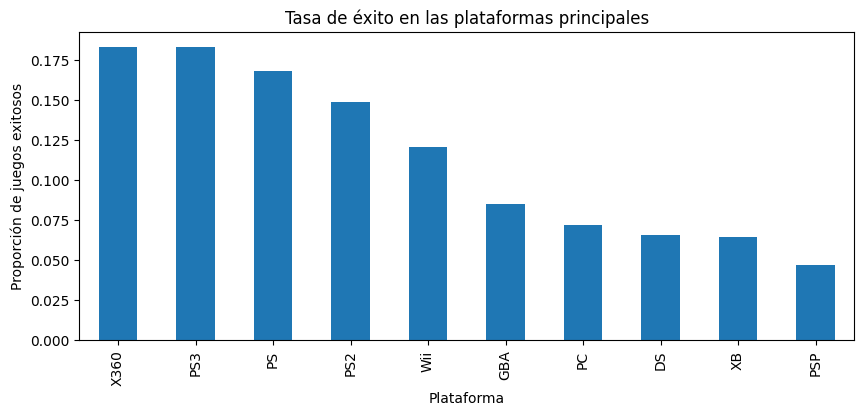

In [30]:
# Tasa de éxito por plataforma (top 10 más frecuentes)
top_platforms = df['Platform'].value_counts().head(10).index
platform_success = df[df['Platform'].isin(top_platforms)] \
    .groupby('Platform')['Successful'].mean() \
    .sort_values(ascending=False)

platform_success.plot(kind='bar', figsize=(10,4))
plt.title("Tasa de éxito en las plataformas principales")
plt.xlabel("Plataforma")
plt.ylabel("Proporción de juegos exitosos")
plt.show()

### Interpretación

El análisis por plataforma muestra, en primer lugar, que no todas las plataformas tienen la misma representación en el dataset. **DS** y **PS2** son las plataformas con mayor número de videojuegos, seguidas por **PS3**, **Wii** y **X360**.

Sin embargo, al observar la **tasa de éxito por plataforma**, se aprecia que las plataformas con más juegos no son necesariamente las que presentan una mayor proporción de títulos exitosos. En particular, **X360** y **PS3** destacan por mostrar las tasas de éxito más altas dentro de las plataformas principales, mientras que otras como **PSP** presentan valores más bajos.

Esto sugiere que la plataforma es una variable relevante para la predicción, ya que no solo influye el volumen de juegos publicados, sino también el contexto comercial asociado a cada sistema.


## 6. Publishers principales y tasa de éxito por publisher

Por último, se estudian las editoras con mayor presencia en el dataset y su relación con el éxito.

In [31]:
# Mostramos los publishers que más aparecen en el dataset
df['Publisher'].value_counts().head(15)

,count
Publisher,
Electronic Arts,1351
Activision,975
Namco Bandai Games,932
Ubisoft,921
Konami Digital Entertainment,832
THQ,715
Nintendo,703
Sony Computer Entertainment,683
Sega,639


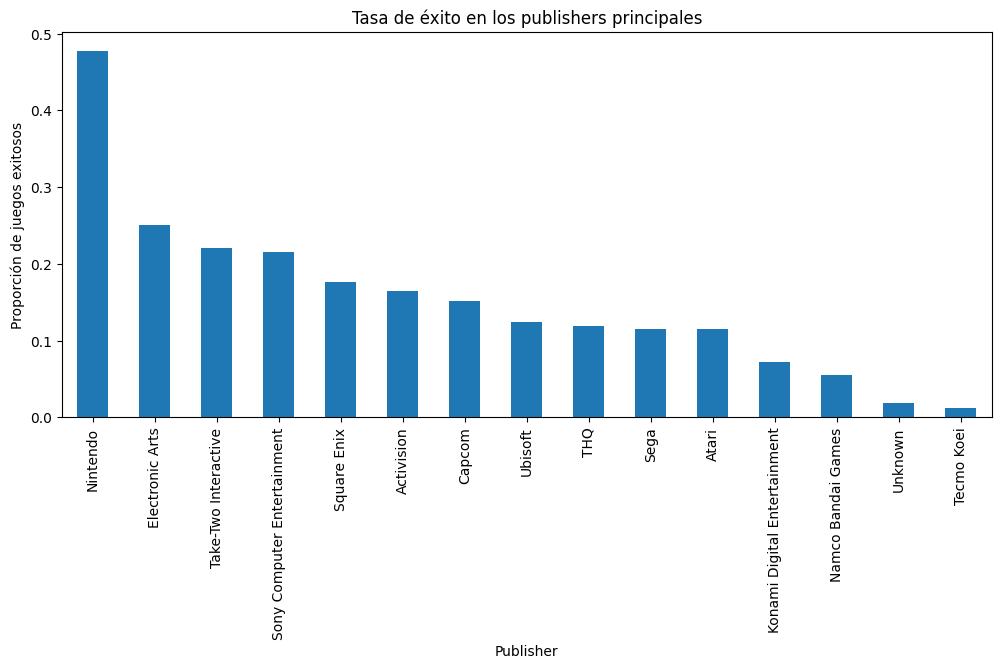

In [32]:
# Seleccionamos los 15 publishers más frecuentes
top_publishers = df['Publisher'].value_counts().head(15).index

# Calculamos la tasa de éxito en esos publishers
publisher_success = df[df['Publisher'].isin(top_publishers)] \
    .groupby('Publisher')['Successful'].mean() \
    .sort_values(ascending=False)

# Dibujamos el gráfico
publisher_success.plot(kind='bar', figsize=(12,5))
plt.title("Tasa de éxito en los publishers principales")
plt.xlabel("Publisher")
plt.ylabel("Proporción de juegos exitosos")
plt.show()

### Interpretación

El análisis por publisher muestra diferencias claras en la proporción de videojuegos exitosos entre las editoras principales. En particular, **Nintendo** destaca de forma muy marcada como la publisher con mayor tasa de éxito dentro del grupo analizado, mientras que otras como **Electronic Arts**, **Take-Two Interactive** y **Sony Computer Entertainment** también presentan valores relativamente altos.

Por el contrario, algunos publishers muestran proporciones bastante menores de títulos exitosos, como ocurre en los casos de **Konami Digital Entertainment**, **Namco Bandai Games**, **Unknown** o **Tecmo Koei**.

Estos resultados sugieren que la variable **Publisher** puede ser especialmente relevante para el problema de predicción, ya que probablemente recoge información relacionada con la experiencia de la empresa, su capacidad de distribución, la fortaleza de sus franquicias o su posicionamiento en el mercado. Además, este análisis pone de manifiesto que no basta con observar cuántos juegos publica una compañía, sino también qué proporción de ellos alcanza el éxito.

# Creación de la variable objetivo

## Definición de variables predictoras y variable objetivo

Una vez finalizado el análisis exploratorio, se separan las variables de entrada y la variable objetivo.

In [33]:
# X contiene las variables de entrada del modelo
X = df[['Platform', 'Year', 'Genre', 'Publisher']]

# y contiene la variable objetivo
y = df['Successful']

## División en conjunto de entrenamiento y prueba

Se divide el dataset en dos subconjuntos:

*  uno para entrenar los modelos (80%)
*  otro para evaluar su rendimiento con datos no vistos (20%)

Además, se utiliza stratify=y para mantener la misma proporción de clases en ambos subconjuntos.

In [34]:
# Importamos la función para dividir el dataset
from sklearn.model_selection import train_test_split

# Dividimos en entrenamiento y prueba
# test_size=0.2 indica que el 20% será para prueba
# stratify=y mantiene la proporción de clases
# random_state=42 permite reproducir los resultados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Mostramos dimensiones de cada conjunto
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (13278, 4)
X_test: (3320, 4)
y_train: (13278,)
y_test: (3320,)


# Preprocesamiento
Se aplica imputación de valores faltantes, codificación de variables categóricas y escalado de la variable numérica para que los modelos puedan trabajar correctamente.

In [35]:
# Definimos columnas categóricas y numéricas
categorical_features = ['Platform', 'Genre', 'Publisher']
numeric_features = ['Year']

# Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combinamos ambos tipos de transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)

# Modelos de machine learning y experimentación
En esta fase se entrenan distintos modelos de clasificación para comparar su comportamiento sobre el mismo problema.

La experimentación no se limita a probar varios modelos, sino también a comparar enfoques de distinta naturaleza:

+  un modelo lineal e interpretable: Regresión Logística
+  dos modelos basados en árboles: Random Forest y Gradient Boosting
+  un modelo orientado a encontrar una separación más robusta entre clases: SVM

Además, en algunos modelos se utiliza class_weight='balanced' como estrategia para reducir el impacto del desbalance de clases detectado durante el análisis exploratorio.

**Regresión Logística**

Se utiliza como modelo base por ser sencillo, rápido e interpretable.

In [36]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Platform', 'Genre',
                                                   'Publisher']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

**Random Forest**

Este modelo se incluye por su capacidad para capturar relaciones no lineales y combinaciones entre variables.

In [37]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Platform', 'Genre',
                                                   'Publisher']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

**Gradient Boosting**

Se emplea para comprobar si un modelo de boosting mejora el rendimiento respecto a otras alternativas.

In [38]:
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Platform', 'Genre',
                                                   'Publisher']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

**SVM**

Se prueba SVM por su buen comportamiento en tareas de clasificación y por su capacidad para encontrar fronteras de decisión más complejas.

In [39]:
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42))
])

svm_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Platform', 'Genre',
                                                   'Publisher']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year'])])),
                ('classifier',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

# Entrenamiento de resultados
El dataset presenta desbalance entre clases, ya que la proporción de videojuegos exitosos es claramente menor que la de videojuegos no exitosos. Por este motivo, la métrica accuracy no es suficiente para evaluar correctamente el rendimiento de los modelos, porque un clasificador podría obtener una precisión global alta simplemente prediciendo la clase mayoritaria.

Por ello, la métrica principal utilizada en este proyecto es el F1-score, ya que combina precision y recall en una sola medida y resulta especialmente útil cuando interesa evaluar de forma equilibrada la capacidad del modelo para identificar la clase positiva, que en este caso son los videojuegos exitosos.

Como métrica complementaria, se utiliza también ROC-AUC, ya que permite medir la capacidad general del modelo para discriminar entre ambas clases a distintos umbrales de decisión. De este modo, el análisis no depende únicamente de una clasificación final binaria, sino también de la calidad global de separación entre juegos exitosos y no exitosos.

En consecuencia, aunque se muestra también la accuracy como referencia general, la selección del mejor modelo se basa principalmente en F1-score y ROC-AUC, por ser métricas más adecuadas para este problema.

In [40]:
# Importamos métricas de evaluación
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

In [41]:
# Creamos una función para evaluar cualquier modelo
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f"Modelo: {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        'Model': model_name,
        'Accuracy': acc,
        'F1-score': f1,
        'ROC-AUC': roc
    }

results = []
results.append(evaluate_model(lr_model, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model(rf_model, X_test, y_test, "Random Forest"))
results.append(evaluate_model(gb_model, X_test, y_test, "Gradient Boosting"))
results.append(evaluate_model(svm_model, X_test, y_test, "SVM"))

results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
results_df

Modelo: Logistic Regression
Accuracy: 0.7268
F1-score: 0.4099
ROC-AUC: 0.8281

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82      2909
           1       0.28      0.77      0.41       411

    accuracy                           0.73      3320
   macro avg       0.62      0.74      0.62      3320
weighted avg       0.87      0.73      0.77      3320

Modelo: Random Forest
Accuracy: 0.8431
F1-score: 0.4032
ROC-AUC: 0.7908

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      2909
           1       0.38      0.43      0.40       411

    accuracy                           0.84      3320
   macro avg       0.65      0.66      0.66      3320
weighted avg       0.85      0.84      0.85      3320

Modelo: Gradient Boosting
Accuracy: 0.8846
F1-score: 0.1937
ROC-AUC: 0.8117

Classification Report:
              precision    recall  f1-score   su

,Model,Accuracy,F1-score,ROC-AUC
3,SVM,0.780422,0.460400,0.845893
0,Logistic Regression,0.726807,0.409889,0.828083
2,Gradient Boosting,0.884639,0.193684,0.811712
1,Random Forest,0.843072,0.403207,0.790773


## Discusión de resultados

Los resultados obtenidos muestran diferencias claras entre los modelos evaluados. Aunque todos fueron entrenados sobre el mismo conjunto de datos y con el mismo esquema de preprocesado, su comportamiento frente a la clase positiva fue distinto.

La **Regresión Logística** obtuvo una accuracy de 0.7268, un F1-score de 0.4099 y un ROC-AUC de 0.8281. Destaca especialmente por su recall en la clase positiva (0.77), lo que indica que detecta muchos videojuegos exitosos. Sin embargo, su precisión para esta clase fue baja (0.28), por lo que genera bastantes falsos positivos.

El modelo **Random Forest** alcanzó una accuracy mayor (0.8431), pero su F1-score fue de 0.4032 y su ROC-AUC de 0.7908. Aunque mejora la accuracy global, ofrece un equilibrio más limitado en la detección de la clase positiva, con una precisión de 0.38 y un recall de 0.43 para los videojuegos exitosos.

**Gradient Boosting** fue el modelo con mayor accuracy (0.8846), pero también el que obtuvo el peor F1-score (0.1937) entre los modelos comparados. Esto se explica porque clasifica muy bien la clase mayoritaria, pero detecta muy pocos videojuegos exitosos, como refleja su recall de solo 0.11 para la clase positiva. Por tanto, su alta accuracy resulta engañosa en este contexto.

Por último, **SVM** obtuvo una accuracy de 0.7804, un F1-score de 0.4604 y un ROC-AUC de 0.8459. Aunque no fue el mejor en accuracy, sí fue el mejor en las métricas más relevantes para este problema: F1-score y ROC-AUC. Además, logró un recall de 0.76 en la clase positiva, lo que indica una buena capacidad para detectar videojuegos exitosos.

En conjunto, estos resultados muestran que la accuracy no era suficiente para decidir el mejor modelo, ya que el dataset presenta desbalance entre clases. En este contexto, métricas como F1-score y ROC-AUC permiten valorar mejor si el modelo identifica correctamente la clase de interés.

## Modelo de machine learning seleccionado

El modelo finalmente seleccionado fue **SVM**, ya que presentó el mejor equilibrio entre detección de la clase positiva y capacidad global de discriminación. En concreto, obtuvo el mejor **F1-score** (0.4604) y el mejor **ROC-AUC** (0.8459) entre los modelos evaluados.

La elección de SVM se justifica porque el objetivo del proyecto no era únicamente maximizar la accuracy, sino identificar correctamente los videojuegos exitosos dentro de un conjunto de datos desbalanceado. Desde este punto de vista, SVM resultó más adecuado que el resto de modelos.

Aunque **Gradient Boosting** alcanzó la mayor accuracy, su rendimiento sobre la clase positiva fue claramente inferior, por lo que no se consideró la mejor alternativa. En cambio, SVM mostró un comportamiento más equilibrado y una mayor capacidad para detectar títulos exitosos sin centrarse exclusivamente en la clase mayoritaria.

In [42]:
best_model = svm_model

## Matriz de confusión del mejor modelo

La matriz de confusión permite visualizar los aciertos y errores del modelo seleccionado.

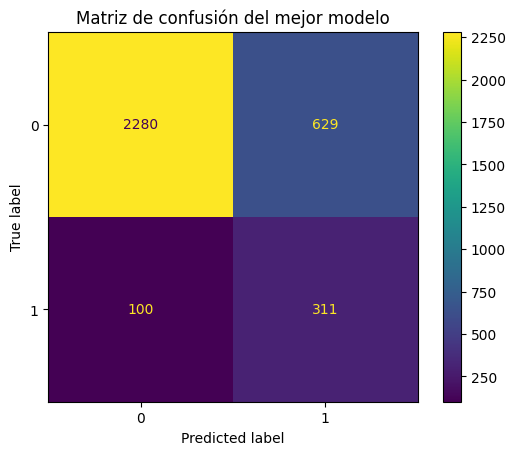

In [43]:
# Importamos herramientas para la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusión del mejor modelo")
plt.show()

### Interpretación

La matriz de confusión permite analizar con más detalle el comportamiento del modelo SVM sobre el conjunto de prueba.

En total, el modelo clasificó correctamente **2280** videojuegos no exitosos y **311** videojuegos exitosos. Sin embargo, también cometió **629 falsos positivos**, es decir, predijo como exitosos videojuegos que en realidad no lo eran, y **100 falsos negativos**, correspondientes a juegos exitosos que el modelo no logró identificar correctamente.

Estos resultados muestran que el modelo tiene una buena capacidad para detectar la clase positiva, ya que el número de falsos negativos es relativamente bajo en comparación con los verdaderos positivos. Esto es coherente con el recall elevado obtenido para la clase de videojuegos exitosos.

No obstante, el número de falsos positivos es considerable, lo que indica que el modelo tiende a etiquetar como exitosos algunos juegos que finalmente no lo son. Por tanto, el SVM seleccionado ofrece un buen equilibrio general, pero todavía presenta margen de mejora, especialmente en la precisión de la clase positiva.

## Curva ROC del mejor modelo

La curva ROC permite visualizar la capacidad del modelo para separar ambas clases a distintos umbrales de decisión.

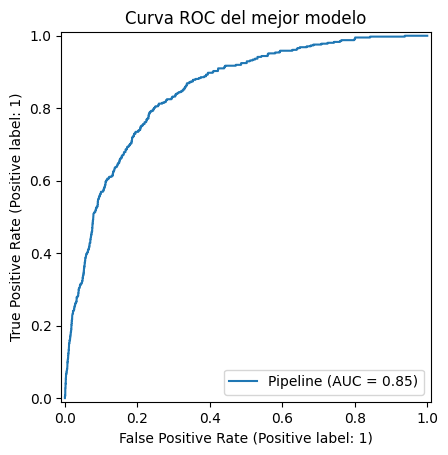

In [44]:
# Importamos la herramienta para representar la curva ROC
from sklearn.metrics import RocCurveDisplay

# Dibujamos la curva ROC
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC del mejor modelo")
plt.show()

### Interpretación

La curva ROC muestra la capacidad del modelo para distinguir entre videojuegos exitosos y no exitosos a distintos umbrales de decisión. En este caso, la curva se sitúa claramente por encima de la diagonal correspondiente a un clasificador aleatorio, lo que indica que el modelo tiene una capacidad de discriminación adecuada.

El valor de **ROC-AUC = 0.8459** confirma este resultado, ya que se encuentra bastante por encima de 0.5 y relativamente próximo a 1. Esto significa que el modelo SVM logra separar razonablemente bien ambas clases y asignar puntuaciones más altas, en promedio, a los videojuegos exitosos que a los no exitosos.

Por tanto, la curva ROC refuerza la elección de SVM como modelo final, ya que muestra un buen rendimiento global incluso cuando se consideran distintos umbrales de clasificación.

# Conclusión

En este proyecto se ha abordado un problema de clasificación supervisada con el objetivo de predecir si un videojuego será exitoso o no a partir de variables como la plataforma, el año de lanzamiento, el género y la publisher.

A lo largo del trabajo se realizó un análisis exploratorio de datos que permitió identificar varias ideas relevantes. En primer lugar, se observó que las ventas globales presentan una distribución muy sesgada, con pocos juegos que alcanzan cifras muy altas y una gran mayoría con ventas reducidas. Además, se detectó un desbalance de clases, ya que los videojuegos considerados exitosos representan una proporción claramente menor del total. También se encontraron diferencias interesantes en la tasa de éxito según el género, la plataforma, el año y la editora.

Posteriormente, se prepararon los datos mediante tratamiento de valores faltantes, codificación de variables categóricas y escalado de la variable numérica. Después se entrenaron distintos modelos de machine learning: Regresión Logística, Random Forest, Gradient Boosting y SVM.

Tras comparar los resultados, el modelo SVM fue seleccionado como la mejor opción, ya que obtuvo el mejor equilibrio en las métricas más relevantes para este problema, especialmente en F1-score y ROC-AUC. Esto indica que fue el modelo más adecuado para detectar videojuegos exitosos dentro de un conjunto de datos desbalanceado.

Como limitaciones del proyecto, hay que señalar que el modelo trabaja con un número reducido de variables predictoras y que el criterio de éxito se ha simplificado mediante un umbral fijo de ventas. En futuros trabajos, se podría mejorar el rendimiento incorporando nuevas variables, ajustando hiperparámetros o probando técnicas específicas para tratar el desbalance de clases.

En conjunto, el proyecto permite concluir que existen patrones en los datos que hacen posible predecir, hasta cierto punto, el éxito comercial de un videojuego, y que el uso adecuado de métricas y modelos resulta fundamental para obtener una evaluación realista del problema.